# Описание задачи

**Практическое задание №4 (12 баллов). Предсказание рейтинга настольных игр**

В этом задании вам предстоит предсказывать средний рейтинг настольной игры (Rating Average) на основе различных характеристик игр. Вам будут доступны данные о каждой игре: название, количество игроков, продолжительность партии, жанр, возрастное ограничение, количество рейтингов и отзывы пользователей, год выпуска и прочие метаданные.

Данный датасет основан на информации, собранной с веб-сайта BoardGameGeek (BGG) в феврале 2021 года. BGG — крупнейшая онлайн-коллекция данных о настольных играх, которая включает сведения более чем о 100 000 играх.

Набор данных, предоставленный для этого соревнования, содержит все игры с рейтингами (около 20 000 игр) на момент сбора.

Ваша задача — построить модель, которая сможет предсказывать средний рейтинг игры на основе предоставленных характеристик.

Что нужно сделать
1. Принять участие в соревновании на Kaggle по [ссылке](https://www.kaggle.com/competitions/games-rating/overview).
2. Разработать и оформить решение в ноутбуке:
* Исследование и анализ датасета.
* Предобработка данных.
* Feature Engineering (если необходимо).
* Подбор признаков, их анализ и оценка важности.
* Обучение нескольких моделей, их сравнение.
* Подбор гиперпараметров.
* Выбор лучшей модели и объяснение выбора.
* Предсказание на тестовых данных.
* Результат должен быть воспроизводимым!
3. Закрепить в ноутбуке скриншот с лидерборда Kaggle.
4. Прикрепить ноутбук (.ipynb) с решением на платформу.

Требования к ноутбуку:
* Комментарии и пояснения к коду.
* Выводы к каждому этапу (анализ данных, предобработка, обучение).
* Код должен быть чистым и читаемым.

|**Критерии оценивания**||
|:---|:---|
|Анализ данных и их предобработка	|0-3 балла|
|Feature Engineering и отбор признаков	|0-2 балла|
|Выбор и обучение нескольких моделей	|0-3 балла|
|Подбор гиперпараметров и объяснение выбора лучшей модели	|0-2 балла|
|Результат на Kaggle	|0-1 балл|
|Качество оформления ноутбука (чистый код, комментарии, выводы)	|0-1 балл|
|**Итого**	|**12 баллов**|


# Импортирование библиотек и создание констант

In [114]:
# базовые
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# для считывания датасетов с Kaggle
import opendatasets as od

# scikit-learn
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


In [115]:
# далее random_state=SEED
SEED = 42

In [116]:
# целевая переменная
target_col = 'Rating Average'

# Считывание данных и первичный обзор

In [117]:
# Загрузим датасет на прямую с kaggle
# Для автоматическй загрузки надо положить файл kaggle.json в папку с ноутбуком
# kaggle.json скачивается в настройках Kaggle в разделе Legacy API Credentials
dataset_url = 'https://www.kaggle.com/competitions/games-rating/overview'

od.download(dataset_url)

train = pd.read_csv('./games-rating/train_data.csv')
test = pd.read_csv('./games-rating/test_data.csv')
sample_submit = pd.read_csv('./games-rating/sample_submition.csv')

Skipping, found downloaded files in "./games-rating" (use force=True to force download)


**Посмотрим**, как считалось и выведем общую информацию.

In [118]:
train

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
3,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"
4,291457.0,Gloomhaven: Jaws of the Lion,2020.0,1,4,120,14,8392,"8,87",6,"3,55",21609.0,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15252,1410.0,Trouble,1965.0,2,4,45,4,3255,"3,79",20339,"1,05",4962.0,Roll / Spin and Move,Children's Games
15253,16398.0,War,0.0,2,2,30,4,1340,"2,28",20340,1,427.0,NaN,Children's Games
15254,5048.0,Candy Land,1949.0,2,4,30,3,4006,"3,18",20342,"1,08",5788.0,Roll / Spin and Move,Children's Games
15255,5432.0,Chutes and Ladders,-200.0,2,6,30,3,3783,"2,86",20343,"1,02",4400.0,"Dice Rolling, Grid Movement, Race, Roll / Spin...",Children's Games


In [119]:
# процент дублей
for df in [train, test]:
    print( (len(df) - len( df.drop_duplicates() )) * 100 / len(df) )

0.0
0.0


In [120]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  str    
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  str    
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  str    
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  str    
 13  Domains             7608 non-null   str    
dtypes: float64(3), int64(6), str(5)
memory usage: 2.8 MB


In [121]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 5086 entries, 0 to 5085
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5080 non-null   float64
 1   Name                5086 non-null   str    
 2   Year Published      5086 non-null   float64
 3   Min Players         5086 non-null   int64  
 4   Max Players         5086 non-null   int64  
 5   Play Time           5086 non-null   int64  
 6   Min Age             5086 non-null   int64  
 7   Users Rated         5086 non-null   int64  
 8   BGG Rank            5086 non-null   int64  
 9   Complexity Average  5086 non-null   str    
 10  Owned Users         5080 non-null   float64
 11  Mechanics           4688 non-null   str    
 12  Domains             2576 non-null   str    
dtypes: float64(3), int64(6), str(4)
memory usage: 896.3 KB


**Промежуточный вывод.** Дубей нет, есть пропущенные значения, причём в поле ```Domains``` около половины пропущенных значений.


**Посмотрим** на численные величины.

In [122]:
train.describe()

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Owned Users
count,15247.000000,15256.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15240.000000
mean,108221.590214,1984.144140,2.021236,5.642918,92.801337,9.581766,819.530773,10186.327784,1372.209843
std,98862.566448,211.725679,0.696323,12.551944,607.611378,3.671560,3286.396397,5863.744570,4681.296849
min,1.000000,-3500.000000,0.000000,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000
25%,10907.000000,2001.000000,2.000000,4.000000,30.000000,8.000000,55.000000,5103.000000,146.000000
50%,88316.000000,2011.000000,2.000000,4.000000,45.000000,10.000000,119.000000,10171.000000,308.000000
75%,193045.500000,2016.000000,2.000000,6.000000,90.000000,12.000000,379.000000,15280.000000,856.250000
max,331787.000000,2022.000000,10.000000,999.000000,60000.000000,25.000000,102214.000000,20344.000000,155312.000000


In [123]:
test.describe()

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Owned Users
count,5080.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5080.000000
mean,108200.202559,1984.567047,2.015140,5.760126,86.774479,9.660637,905.289029,10132.581007,1517.200984
std,98148.143108,220.714812,0.672224,21.339524,287.215962,3.565713,4113.427066,5900.401636,5988.373330
min,2.000000,-3000.000000,0.000000,0.000000,0.000000,0.000000,30.000000,2.000000,10.000000
25%,11428.750000,2001.000000,2.000000,4.000000,30.000000,8.000000,56.000000,5052.250000,147.000000
50%,90096.000000,2011.000000,2.000000,4.000000,45.000000,10.000000,122.000000,10194.000000,313.000000
75%,192671.250000,2016.000000,2.000000,6.000000,90.000000,12.000000,403.750000,15216.750000,880.000000
max,329465.000000,2021.000000,8.000000,999.000000,14400.000000,21.000000,101853.000000,20341.000000,154531.000000


**Промежуточный вывод:** 
* ```ID``` — не нужен.
* ```Year Published``` — отрицательные значения можно преобразовать в ```Game Age```.
* ```Min Players``` — ноль игроков, непонятно, что за игра или игры, или это замаскированные пропущенные значения.
* ```Max Players``` — огромный разброс. 999 явный выброс.
* ```Play Time``` — время скорее всего в минутах, 14400 или 10 суток — выброс.
* ```Min Age``` — от нуля до 21, хорошее распределение (при логарифмировании следует ввести поправку на нулевые значения ```np.log1p```).
* ```Users Rated``` — огромный разброс, есть выбросы.
* ```BGG Rank``` — хорошие данные, с большим размахом.
* ```Owned Users``` — похоже, что есть выбросы, либо данные сильно перекошены.
  

**Проверим** совпадения колонок в обоих выборках.

In [124]:
# Проверим, если колонки train и test совпадают
train.columns.drop([target_col]).equals(test.columns)


True

**Промежуточный вывод.** Колонки (признаки, фичи) — должны совпадать и в ```train```, и в ```test```. Так как мы будем преобразовывать данные, то нам надо делать одно и тоже сразу в двух наборах. Причём, если мы добавляем вычисленный признак (мода, медиана), то вычисляем только по ```train```, а добавляем эти значения и туда, и туда.


**Посмотрим** на строковые величины.

In [125]:
train.describe(include=[str, 'object']) # добавляем 'object', для обратной совместимости с pandas < 3.0

,Name,Rating Average,Complexity Average,Mechanics,Domains
count,15257,15257,15257,14057,7608
unique,15045,610,377,5898,39
top,Robin Hood,"6,50",1,Hand Management,Wargames
freq,6,89,1723,327,2236


In [126]:
test.describe(include=[str, 'object'])

,Name,Complexity Average,Mechanics,Domains
count,5086,5086,4688,2576
unique,5056,338,2386,28
top,Clue,1,Hexagon Grid,Wargames
freq,3,580,113,793


In [127]:
# Соотношение уникальных значений по выбранному полю
check_col = 'Name'
for df in [train, test]:
    print( round( df[check_col].nunique() / df.shape[0], 4) )

0.9861
0.9941


In [128]:
# Соотношение пропущенных значений по выбранному полю
check_col = 'Mechanics'
for df in [train, test]:
    print( round( 1 - df[check_col].dropna().shape[0] / df[check_col].shape[0], 4) )

0.0787
0.0783


**Промежуточный вывод:** 
* ```Name``` — этот признак не нужен, 99% уникальных значений будут только "отвлекать" модель.
* ```Rating Average, Complexity Average``` — строковые данные, их следует перевести в числовые.
* ```Mechanics``` — сильный разброс (~33% уникальных значений, ~1–2% частота самого популярного значения). Требует отдельного разбора (укрупнения и/или разбиения). Есть пропущенные значения, около 8%.
* ```Domains``` — хорошо скучкованы (~1% уникальных, ~33% самого полулярного). Много пропущенных значений (~50%). Придётся либо удалять этот признак, либо заполнять медианным значением, в любом случае, вряд ли он будет оказывать хорошее влияние на предсказание.



## Вывод по обзору

Данные требуют преварительной обработки перед обучением модели. Обработку следует проводить сразу на двух выборках. Вычисления моды, медианы делаем только на тренировочных данных, так, любые тестовые данные не будут влиять на вычисления и они (вычисления) останутся стабильными.

# Предварительная обработка

## Преобразование строковых величин в числовые

В текущем датасете мы получили 'Rating Average', 'Complexity Average', заполненные, как числа, только с десятичным разделителем "запятая", а не "точка", как стоит по умолчанию в функции ```pd.read_csv()```. 

In [129]:
# Выберем колонку
sel_col = 'Complexity Average'

In [130]:
# Количество пропущенных значений
( train[sel_col].isna().sum().sum(), test[sel_col].isna().sum().sum(),)

(np.int64(0), np.int64(0))

Пропущенных значений нет, делаем замену "в лоб".

In [131]:
for df in [train, test]:
    df[sel_col] = (
        df[sel_col]
            .str.replace(',', '.', regex=False)
            .astype(float)
    )

In [132]:
train[sel_col]

0        3.86
1        3.91
2        3.24
3        4.22
4        3.55
         ... 
15252    1.05
15253    1.00
15254    1.08
15255    1.02
15256    1.16
Name: Complexity Average, Length: 15257, dtype: float64

In [133]:
test[sel_col]

0       2.84
1       3.59
2       4.14
3       3.41
4       3.86
        ... 
5081    1.03
5082    1.08
5083    1.05
5084    1.11
5085    1.05
Name: Complexity Average, Length: 5086, dtype: float64

In [134]:
# Выберем колонку
sel_col = 'Rating Average'

In [135]:
# Количество пропущенных значений  (целевая колонка, смотрим только в train)
train[sel_col].isna().sum().sum()

np.int64(0)

Пропущенных значений нет, делаем замену "в лоб".

In [136]:
for df in [train]:
    df[sel_col] = (
        df[sel_col]
            .str.replace(',', '.', regex=False)
            .astype(float)
    )

In [137]:
train[sel_col]

0        8.79
1        8.66
2        8.43
3        8.70
4        8.87
         ... 
15252    3.79
15253    2.28
15254    3.18
15255    2.86
15256    2.68
Name: Rating Average, Length: 15257, dtype: float64

## Преобразование года издания в возраст игры

In [138]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  str    
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  float64
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  float64
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  str    
 13  Domains             7608 non-null   str    
dtypes: float64(5), int64(6), str(3)
memory usage: 2.7 MB


Точкой отсчёта будет конец 2025 года.

In [139]:
for df in [train, test]:
    df['Game Age'] = 2025 - df['Year Published']

train['Game Age'].value_counts()

Game Age
9.0       963
7.0       949
8.0       941
10.0      852
6.0       844
         ... 
94.0        1
1625.0      1
151.0       1
2225.0      1
3325.0      1
Name: count, Length: 164, dtype: int64

In [140]:
train[train['Game Age'].isna() == True]

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
10496,NaN,Hus,NaN,2,2,40,0,38,6.28,13986,2.0,NaN,NaN,NaN,NaN


In [141]:
test[test['Game Age'].isna() == True]

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age


In [142]:
train['Game Age'].describe()

count    15256.000000
mean        40.855860
std        211.725679
min          3.000000
25%          9.000000
50%         14.000000
75%         24.000000
max       5525.000000
Name: Game Age, dtype: float64

In [143]:
median_age = train['Game Age'].median()
median_age

14.0

В данной тестовой выборки пропущенных значений нет, но мы сделем это на всякий случай, если вдруг они к нам придут, то заполнятся медианным значением из тренировочной выборки.

In [144]:
train['Game Age'] = train['Game Age'].fillna(median_age)
test['Game Age'] = test['Game Age'].fillna(median_age)

Примечание. Хотя игра Hus гуглится и может быть разновидностью древней популярной игры и медианный возраст $14$, вроде, не очень подходит, но менять вручную мы его не будем, на случай, если нам будут поступать другие игры с пропущенными значениями.

## Удаление "шума"

In [145]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  str    
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  float64
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  float64
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  str    
 13  Domains             7608 non-null   str    
 14  Game Age            15257 non-null  float64
dtypes: float64(6), int64(6), str(3)
memory usage: 2.8 MB


In [146]:
cols_to_drop = ['ID', 'Year Published', 'Name']

In [147]:
# Проверим, если колонки train и test совпадают
train.columns.drop([target_col]).equals(test.columns)


True

In [148]:
train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

In [149]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Min Players         15257 non-null  int64  
 1   Max Players         15257 non-null  int64  
 2   Play Time           15257 non-null  int64  
 3   Min Age             15257 non-null  int64  
 4   Users Rated         15257 non-null  int64  
 5   Rating Average      15257 non-null  float64
 6   BGG Rank            15257 non-null  int64  
 7   Complexity Average  15257 non-null  float64
 8   Owned Users         15240 non-null  float64
 9   Mechanics           14057 non-null  str    
 10  Domains             7608 non-null   str    
 11  Game Age            15257 non-null  float64
dtypes: float64(4), int64(6), str(2)
memory usage: 2.2 MB


In [150]:
# Проверим, если колонки train и test совпадают
train.columns.drop([target_col]).equals(test.columns)


True

## Обработка поля *Owned Users*

In [151]:
sel_col = 'Owned Users'

In [152]:
train[train[sel_col].isna() == True]

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
2100,2,4,45,10,565,7.13,2830,2.00,NaN,"Hand Management, Take That, Set Collection",NaN,9.0
2664,2,4,45,10,360,7.20,3592,2.14,NaN,"Hand Management, Set Collection, Take That",NaN,9.0
2771,2,4,45,10,336,7.19,3741,2.13,NaN,"Hand Management, Set Collection, Take That",NaN,9.0
4331,3,4,360,12,221,6.68,5809,3.00,NaN,"Area Movement, Variable Player Powers",NaN,26.0
6880,2,2,120,12,94,6.72,9204,3.00,NaN,"Dice Rolling, Events, Grid Movement, Hexagon G...",NaN,40.0
6970,3,12,45,10,216,5.97,9319,1.38,NaN,"Deduction, Hidden Roles, Voting",NaN,44.0
7555,1,1,60,14,49,7.84,10077,2.83,NaN,NaN,NaN,4.0
8086,2,2,20,10,110,6.26,10778,2.00,NaN,NaN,NaN,35.0
8125,3,8,45,12,137,6.05,10837,2.00,NaN,NaN,NaN,26.0
8762,2,4,30,12,49,7.20,11671,2.00,NaN,NaN,NaN,13.0


In [153]:
train[sel_col].describe()

count     15240.000000
mean       1372.209843
std        4681.296849
min           0.000000
25%         146.000000
50%         308.000000
75%         856.250000
max      155312.000000
Name: Owned Users, dtype: float64

У игры нуль владельцев, похоже на выброс.

In [154]:
train[train[sel_col] == 0]

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
10061,1,4,120,13,30,9.22,13401,3.4,0.0,"Area Majority / Influence, Cooperative Game, E...",NaN,2025.0


In [155]:
test[test[sel_col] == 0]

,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age


Заменим нули на Nan, чтобы потом со всеми Nan заменить на median

In [156]:
for df in [train, test]:
    df[sel_col] = df[sel_col].replace(0, np.nan)

In [157]:
train.sort_values(sel_col).dropna().head()

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
15048,2,2,0,0,41,1.43,20070,3.00,3.0,"Dice Rolling, Roll / Spin and Move","Abstract Games, Thematic Games",14.0
10593,1,6,180,12,31,9.23,14125,2.80,7.0,"Dice Rolling, Grid Movement, Modular Board, Va...","Strategy Games, Wargames",16.0
13988,2,5,120,12,35,4.79,18645,4.17,9.0,"Area Majority / Influence, Area Movement, Modu...","Strategy Games, Thematic Games",14.0
10307,2,4,20,8,76,6.03,13734,1.50,13.0,"Dice Rolling, Set Collection",Family Games,13.0
12377,2,2,10,6,34,5.76,16525,1.00,13.0,Pattern Building,Abstract Games,14.0


In [158]:
train.sort_values(sel_col).dropna().tail()

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
197,2,4,20,10,56013,7.23,284,1.19,92896.0,"Hand Management, Player Elimination, Score-and...",Family Games,13.0
12,2,2,30,10,60302,8.11,17,2.23,94343.0,"Card Drafting, Drafting, Set Collection, Sudde...",Strategy Games,10.0
124,2,5,60,8,71611,7.42,174,1.85,97463.0,"Card Drafting, End Game Bonuses, Hand Manageme...",Family Games,21.0
44,2,7,30,10,84371,7.75,61,2.33,112410.0,"Card Drafting, Drafting, Hand Management, Set ...","Family Games, Strategy Games",15.0
74,2,4,45,8,102214,7.61,99,2.41,155312.0,"Action Points, Cooperative Game, Hand Manageme...","Family Games, Strategy Games",17.0


Огромный разброс, но вполне корректный. Смело заполняем пропущенные значения медианой из train.

In [159]:
median_owners = train[sel_col].median()
median_owners

308.0

In [160]:
for df in [train, test]:
    df[sel_col] = df[sel_col].fillna(median_owners)

In [161]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Min Players         15257 non-null  int64  
 1   Max Players         15257 non-null  int64  
 2   Play Time           15257 non-null  int64  
 3   Min Age             15257 non-null  int64  
 4   Users Rated         15257 non-null  int64  
 5   Rating Average      15257 non-null  float64
 6   BGG Rank            15257 non-null  int64  
 7   Complexity Average  15257 non-null  float64
 8   Owned Users         15257 non-null  float64
 9   Mechanics           14057 non-null  str    
 10  Domains             7608 non-null   str    
 11  Game Age            15257 non-null  float64
dtypes: float64(4), int64(6), str(2)
memory usage: 2.2 MB


## Обзор нулевых значений

In [162]:
train.describe()

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Game Age
count,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000
mean,2.021236,5.642918,92.801337,9.581766,819.530773,6.399775,10186.327784,1.991064,1371.044242,40.854100
std,0.696323,12.551944,607.611378,3.671560,3286.396397,0.936488,5863.744570,0.848816,4678.817365,211.718852
min,0.000000,0.000000,0.000000,0.000000,30.000000,1.050000,1.000000,0.000000,3.000000,3.000000
25%,2.000000,4.000000,30.000000,8.000000,55.000000,5.820000,5103.000000,1.330000,146.000000,9.000000
50%,2.000000,4.000000,45.000000,10.000000,119.000000,6.430000,10171.000000,2.000000,308.000000,14.000000
75%,2.000000,6.000000,90.000000,12.000000,379.000000,7.020000,15280.000000,2.540000,855.000000,24.000000
max,10.000000,999.000000,60000.000000,25.000000,102214.000000,9.580000,20344.000000,5.000000,155312.000000,5525.000000


In [163]:
# Обнулим колонку выбора, так сейчас не нужна, потом заведём явно или получим ошибку
sel_col = None

Нулевое количество игроков - явный абсурд. Если нам известно хотя бы одно значение, то заменить им нулевое, вполне допустимая операция, чтобы не завышать средний максимум в *Min Players* можно заменять его медианным значением, можно  даже привязаться к "отрасли" и заменять его мединным значением по полям *Mechanics*, *Domains*.

In [164]:
train[train['Min Players'] == 0]

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
2107,0,0,0,0,804,6.90,2841,2.47,1194.0,NaN,Strategy Games,2025.0
2398,0,2,720,0,218,8.57,3224,3.74,699.0,"Dice Rolling, Hexagon Grid",Wargames,12.0
2662,0,0,0,0,580,6.68,3589,1.70,2670.0,NaN,Family Games,2025.0
4444,0,2,480,0,105,7.99,5967,3.00,464.0,"Dice Rolling, Hexagon Grid",Wargames,11.0
4868,0,2,240,0,106,7.87,6537,2.78,341.0,"Chit-Pull System, Dice Rolling, Hexagon Grid",Wargames,16.0
5261,0,0,360,12,101,7.40,7060,4.29,307.0,"Area Movement, Dice Rolling, Hexagon Grid, Poi...",Wargames,24.0
5487,0,0,0,12,52,8.59,7363,4.86,117.0,"Dice Rolling, Hexagon Grid, Simultaneous Actio...",Wargames,21.0
5547,0,0,90,0,75,8.05,7441,3.00,131.0,Dice Rolling,NaN,7.0
6848,0,0,0,0,36,8.27,9169,1.00,98.0,NaN,NaN,11.0
7166,0,0,0,0,32,8.78,9569,3.33,58.0,"Enclosure, Line Drawing, Paper-and-Pencil, Til...",Abstract Games,20.0


In [165]:
train[train['Max Players'] == 0]

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
2107,0,0,0,0,804,6.90,2841,2.47,1194.0,NaN,Strategy Games,2025.0
2662,0,0,0,0,580,6.68,3589,1.70,2670.0,NaN,Family Games,2025.0
3171,2,0,60,0,199,8.15,4260,2.81,615.0,"Dice Rolling, Hexagon Grid, Simulation",Wargames,9.0
3352,2,0,240,0,292,6.97,4505,3.13,788.0,"Dice Rolling, Modular Board, Variable Player P...",Wargames,17.0
3469,2,0,30,14,283,6.93,4652,1.88,1196.0,"Set Collection, Tile Placement",NaN,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14908,3,0,0,3,106,4.47,19866,1.00,869.0,Set Collection,NaN,2025.0
15025,4,0,30,17,164,4.54,20031,1.00,646.0,NaN,NaN,10.0
15027,2,0,60,12,244,4.84,20035,1.29,770.0,Roll / Spin and Move,NaN,16.0
15189,2,0,5,0,225,3.79,20255,1.38,170.0,Set Collection,Children's Games,105.0


In [166]:
test[test['Max Players'] == 0].shape

(48, 11)

In [167]:
train[(train['Complexity Average'] == 1)].describe()

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Game Age
count,1725.000000,1725.000000,1725.000000,1725.000000,1725.000000,1725.000000,1725.000000,1725.0,1725.000000,1725.000000
mean,2.190725,8.282899,25.543188,7.811014,91.614493,5.753855,14779.850435,1.0,221.051594,49.135652
std,0.743983,14.922148,23.885021,3.672529,115.555750,0.890691,3968.713153,0.0,262.157199,254.553672
min,0.000000,0.000000,0.000000,0.000000,30.000000,1.050000,1775.000000,1.0,6.000000,4.000000
25%,2.000000,4.000000,15.000000,6.000000,40.000000,5.250000,12448.000000,1.0,89.000000,8.000000
50%,2.000000,5.000000,20.000000,8.000000,56.000000,5.800000,15631.000000,1.0,142.000000,12.000000
75%,2.000000,7.000000,30.000000,10.000000,97.000000,6.340000,17889.000000,1.0,248.000000,20.000000
max,7.000000,100.000000,500.000000,25.000000,1687.000000,9.190000,20340.000000,1.0,3137.000000,2025.000000


In [168]:
train[(train['Min Age'] < 1) & (train['Min Age'] >= 0)].sort_values('Min Age')

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
297,1,4,180,0,2258,8.07,415,4.06,5520.0,"Area Majority / Influence, Dice Rolling, Simul...",Wargames,11.0
454,2,2,90,0,2375,7.63,615,2.84,4449.0,"Area Majority / Influence, Campaign / Battle C...",Wargames,15.0
773,3,99,20,0,1589,7.45,1044,1.11,803.0,Paper-and-Pencil,Party Games,2025.0
1012,1,2,300,0,876,7.97,1354,3.26,2370.0,"Campaign / Battle Card Driven, Dice Rolling, M...",Wargames,16.0
1024,1,6,180,0,1117,7.71,1368,2.71,2378.0,"Action Points, Campaign / Battle Card Driven, ...",Wargames,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14924,2,4,30,0,36,2.23,19893,1.67,23.0,"Hand Management, Take That, Variable Player Po...",NaN,2025.0
15048,2,2,0,0,41,1.43,20070,3.00,3.0,"Dice Rolling, Roll / Spin and Move","Abstract Games, Thematic Games",14.0
15057,2,4,30,0,71,3.29,20082,1.56,74.0,Roll / Spin and Move,NaN,19.0
15079,2,7,45,0,197,4.74,20110,1.31,283.0,"Roll / Spin and Move, Set Collection, Trading",NaN,65.0


In [169]:
test.shape

(5086, 11)

## Корреляционная матрица числовых признаков

Перед тем как проводить изменения в числовых признках, посмотрим, как они вляют на целевую переменную. Если их вляние мало, то можно попробовать избавиться от них, так как они могут вносить "шум" и заставлять модель подстраиваться под них.

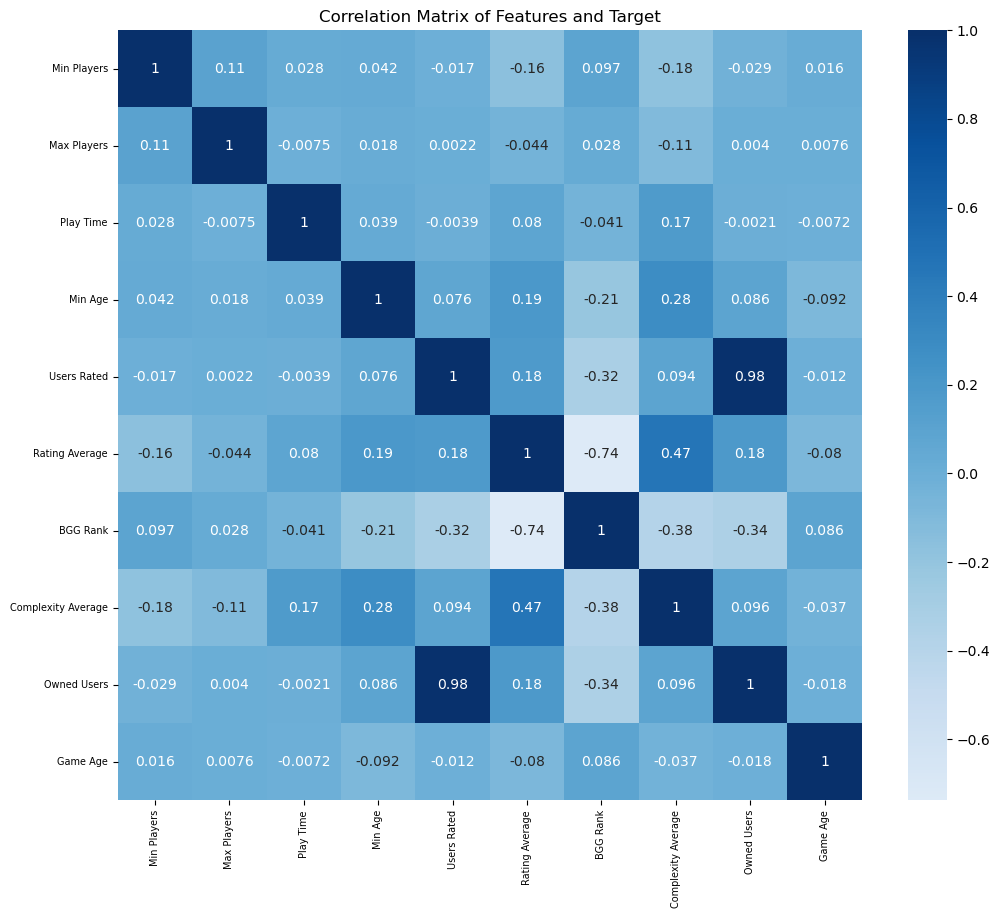

In [170]:
plt.figure(figsize=(12,10))

corr_matrix = train.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap='Blues', center=0, annot=True)

plt.title('Correlation Matrix of Features and Target', fontsize=12)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()

In [171]:
corr_matrix.sort_values(target_col)

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Game Age
BGG Rank,0.096783,0.028195,-0.041497,-0.210580,-0.321523,-0.737897,1.000000,-0.378614,-0.342339,0.085757
Min Players,1.000000,0.108232,0.028361,0.042317,-0.016869,-0.158291,0.096783,-0.175218,-0.028798,0.016228
Game Age,0.016228,0.007567,-0.007231,-0.091800,-0.012103,-0.079545,0.085757,-0.036625,-0.018267,1.000000
Max Players,0.108232,1.000000,-0.007540,0.017650,0.002174,-0.043786,0.028195,-0.105990,0.004013,0.007567
Play Time,0.028361,-0.007540,1.000000,0.038525,-0.003893,0.080006,-0.041497,0.168908,-0.002090,-0.007231
Users Rated,-0.016869,0.002174,-0.003893,0.075521,1.000000,0.175867,-0.321523,0.094232,0.984080,-0.012103
Owned Users,-0.028798,0.004013,-0.002090,0.085973,0.984080,0.184801,-0.342339,0.096403,1.000000,-0.018267
Min Age,0.042317,0.017650,0.038525,1.000000,0.075521,0.187403,-0.210580,0.281572,0.085973,-0.091800
Complexity Average,-0.175218,-0.105990,0.168908,0.281572,0.094232,0.470200,-0.378614,1.000000,0.096403,-0.036625
Rating Average,-0.158291,-0.043786,0.080006,0.187403,0.175867,1.000000,-0.737897,0.470200,0.184801,-0.079545


Очень сильная $0.98$ корреляция между *Users Rated* и *Owned Users* — от неё надо избавляться в первую очередь.

У целевой переменной *Rating Average*:
* Сильная отрицательная корреляция только у **BGG Rank** $-0.74$
* Средняя положительная только у *Complexity Average* $0.47$
* У остальных по модулю слабые, от $0.04$ до $0.19$.

## Объединение *Users Rated* и *Owned Users*

Посмотрим на выбранные поля.

In [172]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Min Players         15257 non-null  int64  
 1   Max Players         15257 non-null  int64  
 2   Play Time           15257 non-null  int64  
 3   Min Age             15257 non-null  int64  
 4   Users Rated         15257 non-null  int64  
 5   Rating Average      15257 non-null  float64
 6   BGG Rank            15257 non-null  int64  
 7   Complexity Average  15257 non-null  float64
 8   Owned Users         15257 non-null  float64
 9   Mechanics           14057 non-null  str    
 10  Domains             7608 non-null   str    
 11  Game Age            15257 non-null  float64
dtypes: float64(4), int64(6), str(2)
memory usage: 2.2 MB


In [173]:
train.describe()

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Game Age
count,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000
mean,2.021236,5.642918,92.801337,9.581766,819.530773,6.399775,10186.327784,1.991064,1371.044242,40.854100
std,0.696323,12.551944,607.611378,3.671560,3286.396397,0.936488,5863.744570,0.848816,4678.817365,211.718852
min,0.000000,0.000000,0.000000,0.000000,30.000000,1.050000,1.000000,0.000000,3.000000,3.000000
25%,2.000000,4.000000,30.000000,8.000000,55.000000,5.820000,5103.000000,1.330000,146.000000,9.000000
50%,2.000000,4.000000,45.000000,10.000000,119.000000,6.430000,10171.000000,2.000000,308.000000,14.000000
75%,2.000000,6.000000,90.000000,12.000000,379.000000,7.020000,15280.000000,2.540000,855.000000,24.000000
max,10.000000,999.000000,60000.000000,25.000000,102214.000000,9.580000,20344.000000,5.000000,155312.000000,5525.000000


Оба поля заполненные, у обоих огромный разброс. Средние величины имеют примерно теже порядки. Пожертвуем интерпретируемостью и сложим их. 

In [174]:
# Заведём новый признак Users Owned+Rated
for df in [train, test]:
    df['Users Owned+Rated'] = df['Owned Users'] + df['Users Rated']
    df.drop(columns=['Owned Users', 'Users Rated'], inplace=True)
    

In [175]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Min Players         15257 non-null  int64  
 1   Max Players         15257 non-null  int64  
 2   Play Time           15257 non-null  int64  
 3   Min Age             15257 non-null  int64  
 4   Rating Average      15257 non-null  float64
 5   BGG Rank            15257 non-null  int64  
 6   Complexity Average  15257 non-null  float64
 7   Mechanics           14057 non-null  str    
 8   Domains             7608 non-null   str    
 9   Game Age            15257 non-null  float64
 10  Users Owned+Rated   15257 non-null  float64
dtypes: float64(4), int64(5), str(2)
memory usage: 2.1 MB


In [176]:
# Проверим, если колонки train и test совпадают
train.columns.drop([target_col]).equals(test.columns)


True

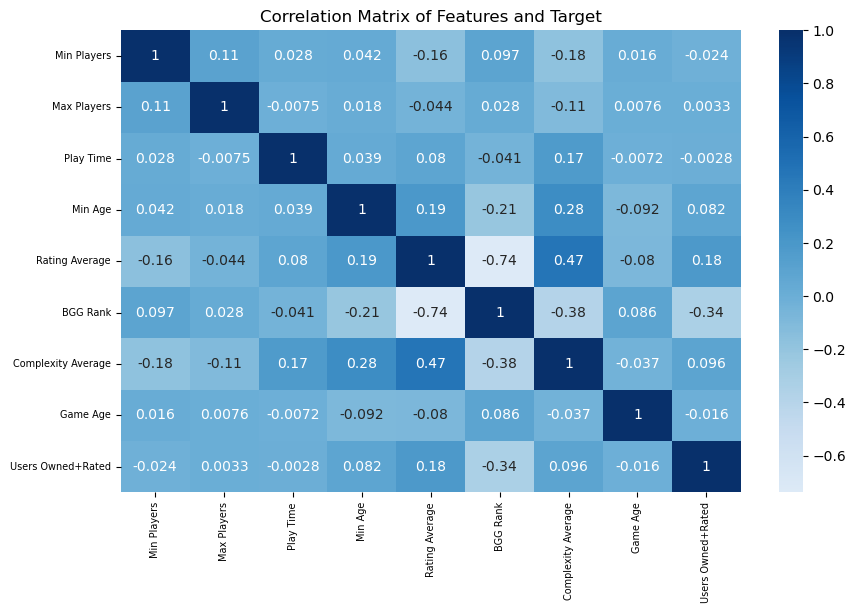

In [177]:
plt.figure(figsize=(10,6))

corr_matrix = train.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap='Blues', center=0, annot=True)

plt.title('Correlation Matrix of Features and Target', fontsize=12)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()

## Обработка категориальных признаков

In [178]:
mask = (train['Mechanics'].isna() == True) & (train['Domains'].isna() == True)

In [179]:
train[mask]

,Min Players,Max Players,Play Time,Min Age,Rating Average,BGG Rank,Complexity Average,Mechanics,Domains,Game Age,Users Owned+Rated
1617,2,2,45,14,7.49,2161,2.20,NaN,NaN,8.0,3753.0
2444,1,5,120,13,7.85,3293,2.44,NaN,NaN,7.0,805.0
2574,2,8,30,10,6.74,3476,1.49,NaN,NaN,26.0,1583.0
2631,1,1,130,10,6.94,3547,1.25,NaN,NaN,9.0,1808.0
2668,2,4,10,7,7.14,3598,1.08,NaN,NaN,10.0,987.0
...,...,...,...,...,...,...,...,...,...,...,...
15190,2,4,30,10,3.09,20256,1.09,NaN,NaN,10.0,649.0
15195,2,8,300,14,1.90,20261,2.18,NaN,NaN,33.0,297.0
15196,2,48,30,3,3.69,20262,1.26,NaN,NaN,495.0,652.0
15202,2,6,45,12,3.38,20268,1.20,NaN,NaN,23.0,965.0


In [180]:
train[train['Domains'].isna() == True]

,Min Players,Max Players,Play Time,Min Age,Rating Average,BGG Rank,Complexity Average,Mechanics,Domains,Game Age,Users Owned+Rated
491,2,6,30,8,7.89,664,1.63,"Card Drafting, Dice Rolling, King of the Hill,...",NaN,5.0,7011.0
745,2,2,60,14,7.53,1012,2.06,"Area Majority / Influence, Hand Management, Ta...",NaN,9.0,8010.0
798,2,2,20,9,8.24,1074,1.93,"Action Points, Hand Management, Line of Sight,...",NaN,6.0,3589.0
813,1,4,90,12,7.02,1093,2.70,Cooperative Game,NaN,8.0,8174.0
827,1,4,90,10,7.12,1109,1.84,Cooperative Game,NaN,8.0,6643.0
...,...,...,...,...,...,...,...,...,...,...,...
15211,2,4,60,8,3.55,20283,2.33,"Auction/Bidding, Card Drafting, Modular Board",NaN,8.0,873.0
15215,2,7,40,14,1.10,20288,1.00,NaN,NaN,6.0,275.0
15219,2,12,45,8,3.10,20292,1.09,"Dice Rolling, Paper-and-Pencil, Team-Based Game",NaN,170.0,903.0
15220,3,8,20,12,4.37,20293,1.21,Voting,NaN,27.0,2501.0


In [181]:
train.Domains.value_counts()

Domains
Wargames                                          2236
Strategy Games                                    1103
Family Games                                      1004
Abstract Games                                     653
Children's Games                                   526
Thematic Games                                     485
Party Games                                        305
Family Games, Strategy Games                       269
Customizable Games                                 190
Strategy Games, Thematic Games                     164
Thematic Games, Wargames                           110
Family Games, Party Games                          101
Family Games, Thematic Games                        89
Abstract Games, Family Games                        84
Children's Games, Family Games                      73
Strategy Games, Wargames                            71
Abstract Games, Strategy Games                      26
Customizable Games, Strategy Games                  21
Pa

In [182]:
train.shape[1] -1 == test.shape[1]

True

### Обработка *Domains* с помощью MultiLabelBinarizer

In [183]:
# Подготовка списков
for df in [train, test]:
    df['Domains_list'] = df['Domains'].fillna('Unknown').str.split(',').apply(lambda x: [i.strip() for i in x])


mlb = MultiLabelBinarizer()

train_encoded = mlb.fit_transform(train['Domains_list'])

test_encoded = mlb.transform(test['Domains_list'])


train_domains = pd.DataFrame(train_encoded, columns=mlb.classes_, index=train.index)
test_domains = pd.DataFrame(test_encoded, columns=mlb.classes_, index=test.index)

# Оставляем только те колонки, которые встречаются больше 50 раз
top_columns = train_domains.columns[train_domains.sum() > 50]

train = pd.concat([train, train_domains[top_columns]], axis=1).drop(['Domains', 'Domains_list'], axis=1)
test = pd.concat([test, test_domains[top_columns]], axis=1).drop(['Domains', 'Domains_list'], axis=1)

In [184]:
print("Количество колонок в train и test совпадает:", train.shape[1] -1 == test.shape[1])

Количество колонок в train и test совпадает: True


In [185]:
train.head()

,Min Players,Max Players,Play Time,Min Age,Rating Average,BGG Rank,Complexity Average,Mechanics,Game Age,Users Owned+Rated,Abstract Games,Children's Games,Customizable Games,Family Games,Party Games,Strategy Games,Thematic Games,Unknown,Wargames
0,1,4,120,14,8.79,1,3.86,"Action Queue, Action Retrieval, Campaign / Bat...",8.0,110378.0,0,0,0,0,0,1,1,0,0
1,2,4,120,14,8.66,3,3.91,"Hand Management, Income, Loans, Market, Networ...",7.0,48002.0,0,0,0,0,0,1,0,0,0
2,1,5,120,12,8.43,4,3.24,"Card Drafting, Drafting, End Game Bonuses, Han...",9.0,151963.0,0,0,0,0,0,1,0,0,0
3,3,6,480,14,8.70,5,4.22,"Action Drafting, Area Majority / Influence, Ar...",8.0,30299.0,0,0,0,0,0,1,1,0,0
4,1,4,120,14,8.87,6,3.55,"Action Queue, Campaign / Battle Card Driven, C...",5.0,30001.0,0,0,0,0,0,1,1,0,0


### Обзор поля *Mechanics*

In [186]:
train.Mechanics.value_counts()

Mechanics
Hand Management                                                                                                                                                              327
Hexagon Grid                                                                                                                                                                 299
Dice Rolling                                                                                                                                                                 276
Roll / Spin and Move                                                                                                                                                         264
Tile Placement                                                                                                                                                               222
                                                                                                         

**Вывод:** признаков слишком много, чтобы их разбить по числовым признакам, с гарантией, что они не окажут влияние на модель, а не зашумлят её. Только как последующее развитие, усложнение модели.

In [187]:
cols_to_drop = [
    'Mechanics', 
]
for df in [train, test]:
    df.drop(columns=cols_to_drop, inplace=True)

In [188]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Min Players         15257 non-null  int64  
 1   Max Players         15257 non-null  int64  
 2   Play Time           15257 non-null  int64  
 3   Min Age             15257 non-null  int64  
 4   Rating Average      15257 non-null  float64
 5   BGG Rank            15257 non-null  int64  
 6   Complexity Average  15257 non-null  float64
 7   Game Age            15257 non-null  float64
 8   Users Owned+Rated   15257 non-null  float64
 9   Abstract Games      15257 non-null  int64  
 10  Children's Games    15257 non-null  int64  
 11  Customizable Games  15257 non-null  int64  
 12  Family Games        15257 non-null  int64  
 13  Party Games         15257 non-null  int64  
 14  Strategy Games      15257 non-null  int64  
 15  Thematic Games      15257 non-null  int64  
 16  Unknown        

In [189]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 5086 entries, 0 to 5085
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Min Players         5086 non-null   int64  
 1   Max Players         5086 non-null   int64  
 2   Play Time           5086 non-null   int64  
 3   Min Age             5086 non-null   int64  
 4   BGG Rank            5086 non-null   int64  
 5   Complexity Average  5086 non-null   float64
 6   Game Age            5086 non-null   float64
 7   Users Owned+Rated   5086 non-null   float64
 8   Abstract Games      5086 non-null   int64  
 9   Children's Games    5086 non-null   int64  
 10  Customizable Games  5086 non-null   int64  
 11  Family Games        5086 non-null   int64  
 12  Party Games         5086 non-null   int64  
 13  Strategy Games      5086 non-null   int64  
 14  Thematic Games      5086 non-null   int64  
 15  Unknown             5086 non-null   int64  
 16  Wargames         

In [190]:
# Проверим, если колонки train и test совпадают
train.columns.drop([target_col]).equals(test.columns)


True

## Логарифмирование *Users Owned+Rated*

In [191]:
train.describe()

,Min Players,Max Players,Play Time,Min Age,Rating Average,BGG Rank,Complexity Average,Game Age,Users Owned+Rated,Abstract Games,Children's Games,Customizable Games,Family Games,Party Games,Strategy Games,Thematic Games,Unknown,Wargames
count,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000
mean,2.021236,5.642918,92.801337,9.581766,6.399775,10186.327784,1.991064,40.854100,2190.575015,0.052173,0.041096,0.015206,0.106771,0.028839,0.109196,0.058137,0.501344,0.160582
std,0.696323,12.551944,607.611378,3.671560,0.936488,5863.744570,0.848816,211.718852,7934.421239,0.222383,0.198519,0.122376,0.308832,0.167360,0.311895,0.234010,0.500015,0.367157
min,0.000000,0.000000,0.000000,0.000000,1.050000,1.000000,0.000000,3.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,30.000000,8.000000,5.820000,5103.000000,1.330000,9.000000,206.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,4.000000,45.000000,10.000000,6.430000,10171.000000,2.000000,14.000000,432.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,2.000000,6.000000,90.000000,12.000000,7.020000,15280.000000,2.540000,24.000000,1235.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,10.000000,999.000000,60000.000000,25.000000,9.580000,20344.000000,5.000000,5525.000000,257526.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [192]:
train.describe()

,Min Players,Max Players,Play Time,Min Age,Rating Average,BGG Rank,Complexity Average,Game Age,Users Owned+Rated,Abstract Games,Children's Games,Customizable Games,Family Games,Party Games,Strategy Games,Thematic Games,Unknown,Wargames
count,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000
mean,2.021236,5.642918,92.801337,9.581766,6.399775,10186.327784,1.991064,40.854100,2190.575015,0.052173,0.041096,0.015206,0.106771,0.028839,0.109196,0.058137,0.501344,0.160582
std,0.696323,12.551944,607.611378,3.671560,0.936488,5863.744570,0.848816,211.718852,7934.421239,0.222383,0.198519,0.122376,0.308832,0.167360,0.311895,0.234010,0.500015,0.367157
min,0.000000,0.000000,0.000000,0.000000,1.050000,1.000000,0.000000,3.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,30.000000,8.000000,5.820000,5103.000000,1.330000,9.000000,206.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,4.000000,45.000000,10.000000,6.430000,10171.000000,2.000000,14.000000,432.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,2.000000,6.000000,90.000000,12.000000,7.020000,15280.000000,2.540000,24.000000,1235.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,10.000000,999.000000,60000.000000,25.000000,9.580000,20344.000000,5.000000,5525.000000,257526.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [193]:
test.describe()

,Min Players,Max Players,Play Time,Min Age,BGG Rank,Complexity Average,Game Age,Users Owned+Rated,Abstract Games,Children's Games,Customizable Games,Family Games,Party Games,Strategy Games,Thematic Games,Unknown,Wargames
count,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000
mean,2.015140,5.760126,86.774479,9.660637,10132.581007,1.991559,40.432953,2421.063508,0.053873,0.043649,0.012780,0.106960,0.032442,0.105977,0.056429,0.493512,0.170271
std,0.672224,21.339524,287.215962,3.565713,5900.401636,0.849247,220.714812,10073.587788,0.225790,0.204334,0.112336,0.309093,0.177188,0.307839,0.230772,0.500007,0.375908
min,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000,46.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,30.000000,8.000000,5052.250000,1.330000,9.000000,209.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,4.000000,45.000000,10.000000,10194.000000,1.920000,14.000000,440.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,6.000000,90.000000,12.000000,15216.750000,2.560000,24.000000,1289.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,8.000000,999.000000,14400.000000,21.000000,20341.000000,4.910000,5025.000000,256041.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Поле *Users Owned+Rated* имеет огромный правый хвост, прологарифмируем его.

In [194]:
sel_col = 'Users Owned+Rated'
train['log_' + sel_col] = np.log(train[sel_col])
test['log_' + sel_col] = np.log(test[sel_col])

train = train.drop(sel_col, axis='columns')
test = test.drop(sel_col, axis='columns')

In [195]:
train.describe()

,Min Players,Max Players,Play Time,Min Age,Rating Average,BGG Rank,Complexity Average,Game Age,Abstract Games,Children's Games,Customizable Games,Family Games,Party Games,Strategy Games,Thematic Games,Unknown,Wargames,log_Users Owned+Rated
count,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000
mean,2.021236,5.642918,92.801337,9.581766,6.399775,10186.327784,1.991064,40.854100,0.052173,0.041096,0.015206,0.106771,0.028839,0.109196,0.058137,0.501344,0.160582,6.353865
std,0.696323,12.551944,607.611378,3.671560,0.936488,5863.744570,0.848816,211.718852,0.222383,0.198519,0.122376,0.308832,0.167360,0.311895,0.234010,0.500015,0.367157,1.367271
min,0.000000,0.000000,0.000000,0.000000,1.050000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.496508
25%,2.000000,4.000000,30.000000,8.000000,5.820000,5103.000000,1.330000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.327876
50%,2.000000,4.000000,45.000000,10.000000,6.430000,10171.000000,2.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,6.068426
75%,2.000000,6.000000,90.000000,12.000000,7.020000,15280.000000,2.540000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,7.118826
max,10.000000,999.000000,60000.000000,25.000000,9.580000,20344.000000,5.000000,5525.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.458876


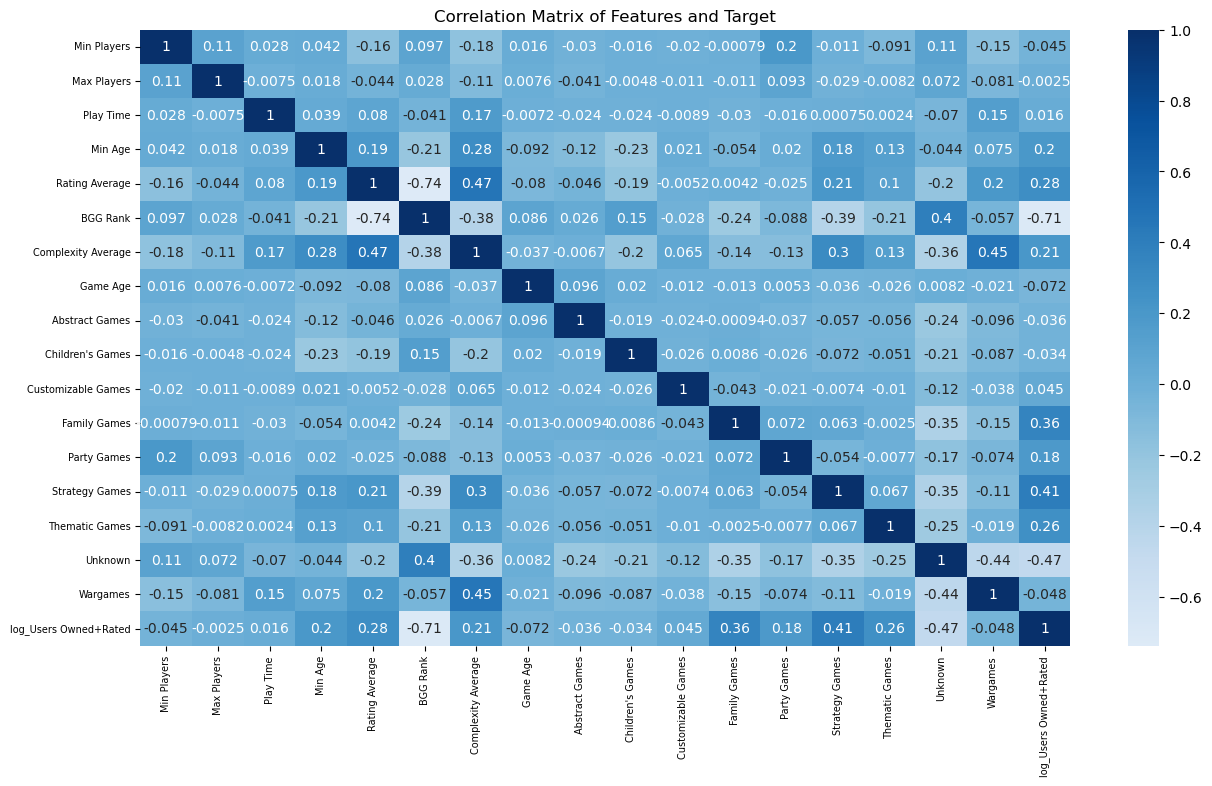

In [196]:
plt.figure(figsize=(15,8))

corr_matrix = train.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap='Blues', center=0, annot=True)

plt.title('Correlation Matrix of Features and Target', fontsize=12)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()

In [197]:
corr_matrix

,Min Players,Max Players,Play Time,Min Age,Rating Average,BGG Rank,Complexity Average,Game Age,Abstract Games,Children's Games,Customizable Games,Family Games,Party Games,Strategy Games,Thematic Games,Unknown,Wargames,log_Users Owned+Rated
Min Players,1.000000,0.108232,0.028361,0.042317,-0.158291,0.096783,-0.175218,0.016228,-0.029590,-0.016272,-0.019943,-0.000791,0.204544,-0.010678,-0.091249,0.109487,-0.149481,-0.044889
Max Players,0.108232,1.000000,-0.007540,0.017650,-0.043786,0.028195,-0.105990,0.007567,-0.041371,-0.004764,-0.010718,-0.010963,0.093301,-0.029369,-0.008196,0.071910,-0.081458,-0.002523
Play Time,0.028361,-0.007540,1.000000,0.038525,0.080006,-0.041497,0.168908,-0.007231,-0.024368,-0.024008,-0.008908,-0.029701,-0.015936,0.000746,0.002409,-0.069946,0.148544,0.015948
Min Age,0.042317,0.017650,0.038525,1.000000,0.187403,-0.210580,0.281572,-0.091800,-0.115771,-0.227594,0.021450,-0.053686,0.020377,0.175714,0.129616,-0.044093,0.074623,0.204483
Rating Average,-0.158291,-0.043786,0.080006,0.187403,1.000000,-0.737897,0.470200,-0.079545,-0.046349,-0.191661,-0.005238,0.004215,-0.024638,0.211129,0.103909,-0.196962,0.202199,0.279463
BGG Rank,0.096783,0.028195,-0.041497,-0.210580,-0.737897,1.000000,-0.378614,0.085757,0.025925,0.146978,-0.027544,-0.244290,-0.088234,-0.392008,-0.206957,0.395473,-0.057130,-0.713393
Complexity Average,-0.175218,-0.105990,0.168908,0.281572,0.470200,-0.378614,1.000000,-0.036625,-0.006680,-0.204046,0.064518,-0.135617,-0.133847,0.297029,0.133427,-0.359036,0.451027,0.206903
Game Age,0.016228,0.007567,-0.007231,-0.091800,-0.079545,0.085757,-0.036625,1.000000,0.096176,0.019703,-0.011838,-0.013409,0.005280,-0.036393,-0.026411,0.008238,-0.021056,-0.071732
Abstract Games,-0.029590,-0.041371,-0.024368,-0.115771,-0.046349,0.025925,-0.006680,0.096176,1.000000,-0.018875,-0.024337,-0.000944,-0.036908,-0.056627,-0.055770,-0.235247,-0.096194,-0.036419
Children's Games,-0.016272,-0.004764,-0.024008,-0.227594,-0.191661,0.146978,-0.204046,0.019703,-0.018875,1.000000,-0.025725,0.008612,-0.025810,-0.072481,-0.051433,-0.207577,-0.086949,-0.034325


Похоже, логарифмирование выявило ещё одну сильную отрицательную корреляцию, $-0.71$ между *BGG Rank* и *log_Users Owned+Rated*.

In [198]:
test.shape

(5086, 17)

## Стандартизация числовых признаков

Стандартизация — это приведение фичей (значений признаков) к единому "масштабу". $20 344$ *BGG Rank* явно больше $5.0$ *Complexity Average*. 

При этом целевой признак мы не трогаем.

In [199]:
target_col

'Rating Average'

In [200]:
# Отделение целевой переменной
X = train.drop(target_col, axis=1) # признаки
y = train[target_col]              # цель
X_pred = test

In [201]:
X.shape, y.shape, X_pred.shape

((15257, 17), (15257,), (5086, 17))

In [202]:
# Создаем скалер с выводом в формате pandas
scaler = StandardScaler().set_output(transform="pandas")

# Обучаем (fit) на тренировочных данных и сразу трансформируем их
# Скалер "запоминает" среднее и стандартное отклонение только для X_train
X_scaled = scaler.fit_transform(X)

# Применяем (transform) те же параметры к тестовым данным
# Важно: здесь используем только .transform(), БЕЗ .fit()
X_pred_scaled = scaler.transform(X_pred)


In [203]:
train_scaled = pd.concat([X_scaled, y], axis='columns')
test_scaled = X_pred_scaled

In [204]:
train_scaled.describe()

,Min Players,Max Players,Play Time,Min Age,BGG Rank,Complexity Average,Game Age,Abstract Games,Children's Games,Customizable Games,Family Games,Party Games,Strategy Games,Thematic Games,Unknown,Wargames,log_Users Owned+Rated,Rating Average
count,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,15257.000000,1.525700e+04,1.525700e+04,1.525700e+04,1.525700e+04,15257.000000
mean,1.490291e-16,-1.490291e-17,7.451454e-18,1.490291e-17,1.192233e-16,1.192233e-16,2.235436e-17,2.794295e-17,-1.490291e-17,4.657159e-17,-1.043204e-16,-2.235436e-17,0.000000,1.490291e-17,5.961163e-17,3.725727e-17,-2.384465e-16,6.399775
std,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,0.936488
min,-2.902821e+00,-4.495800e-01,-1.527364e-01,-2.609812e+00,-1.737058e+00,-2.345771e+00,-1.788000e-01,-2.346159e-01,-2.070197e-01,-1.242615e-01,-3.457359e-01,-1.723242e-01,-0.350116,-2.484468e-01,-1.002691e+00,-4.373804e-01,-2.089893e+00,1.050000
25%,-3.049854e-02,-1.308938e-01,-1.033611e-01,-4.308299e-01,-8.669365e-01,-7.788321e-01,-1.504596e-01,-2.346159e-01,-2.070197e-01,-1.242615e-01,-3.457359e-01,-1.723242e-01,-0.350116,-2.484468e-01,-1.002691e+00,-4.373804e-01,-7.504159e-01,5.820000
50%,-3.049854e-02,-1.308938e-01,-7.867348e-02,1.139156e-01,-2.614078e-03,1.052821e-02,-1.268426e-01,-2.346159e-01,-2.070197e-01,-1.242615e-01,-3.457359e-01,-1.723242e-01,-0.350116,-2.484468e-01,9.973163e-01,-4.373804e-01,-2.087724e-01,6.430000
75%,-3.049854e-02,2.844927e-02,-4.610560e-03,6.586611e-01,8.687007e-01,6.467290e-01,-7.960865e-02,-2.346159e-01,-2.070197e-01,-1.242615e-01,-3.457359e-01,-1.723242e-01,-0.350116,-2.484468e-01,9.973163e-01,-4.373804e-01,5.594987e-01,7.020000
max,1.145879e+01,7.914229e+01,9.859783e+01,4.199507e+00,1.732341e+00,3.544977e+00,2.590381e+01,4.262286e+00,4.830459e+00,8.047542e+00,2.892381e+00,5.803016e+00,2.856197,4.025006e+00,9.973163e-01,2.286339e+00,4.465252e+00,9.580000


In [205]:
X_pred_scaled

,Min Players,Max Players,Play Time,Min Age,BGG Rank,Complexity Average,Game Age,Abstract Games,Children's Games,Customizable Games,Family Games,Party Games,Strategy Games,Thematic Games,Unknown,Wargames,log_Users Owned+Rated
0,-0.030499,-0.130894,-0.053986,0.931034,-1.736887,1.000174,-0.145736,-0.234616,-0.207020,-0.124262,-0.345736,-0.172324,2.856197,4.025006,-1.002691,-0.437380,3.822432
1,-0.030499,-0.290237,0.143515,0.931034,-1.735523,1.883786,-0.098502,-0.234616,-0.207020,-0.124262,-0.345736,-0.172324,2.856197,-0.248447,-1.002691,2.286339,3.751347
2,-0.030499,-0.130894,0.143515,0.931034,-1.735182,2.531769,-0.131566,-0.234616,-0.207020,-0.124262,-0.345736,-0.172324,-0.350116,4.025006,-1.002691,2.286339,3.026255
3,-1.466660,-0.051222,0.036536,1.203407,-1.734840,1.671719,-0.150460,-0.234616,-0.207020,-0.124262,-0.345736,-0.172324,2.856197,-0.248447,-1.002691,-0.437380,3.984763
4,-0.030499,-0.130894,0.044765,1.203407,-1.733988,2.201887,-0.107949,-0.234616,-0.207020,-0.124262,-0.345736,-0.172324,2.856197,-0.248447,-1.002691,-0.437380,3.186557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5081,-0.030499,-0.130894,-0.136278,-1.792693,1.729101,-1.132277,0.114051,-0.234616,4.830459,-0.124262,-0.345736,-0.172324,-0.350116,-0.248447,-1.002691,-0.437380,1.138601
5082,-0.030499,0.187792,-0.078673,0.658661,1.729612,-1.073369,-0.060715,-0.234616,-0.207020,-0.124262,-0.345736,5.803016,-0.350116,-0.248447,-1.002691,-0.437380,1.227189
5083,-0.030499,-0.130894,-0.136278,-1.520321,1.729953,-1.108714,0.029030,-0.234616,4.830459,-0.124262,-0.345736,-0.172324,-0.350116,-0.248447,-1.002691,-0.437380,1.571815
5084,-0.030499,-0.130894,-0.103361,-0.975575,1.730465,-1.038025,0.099881,-0.234616,4.830459,-0.124262,-0.345736,-0.172324,-0.350116,-0.248447,-1.002691,-0.437380,1.727836


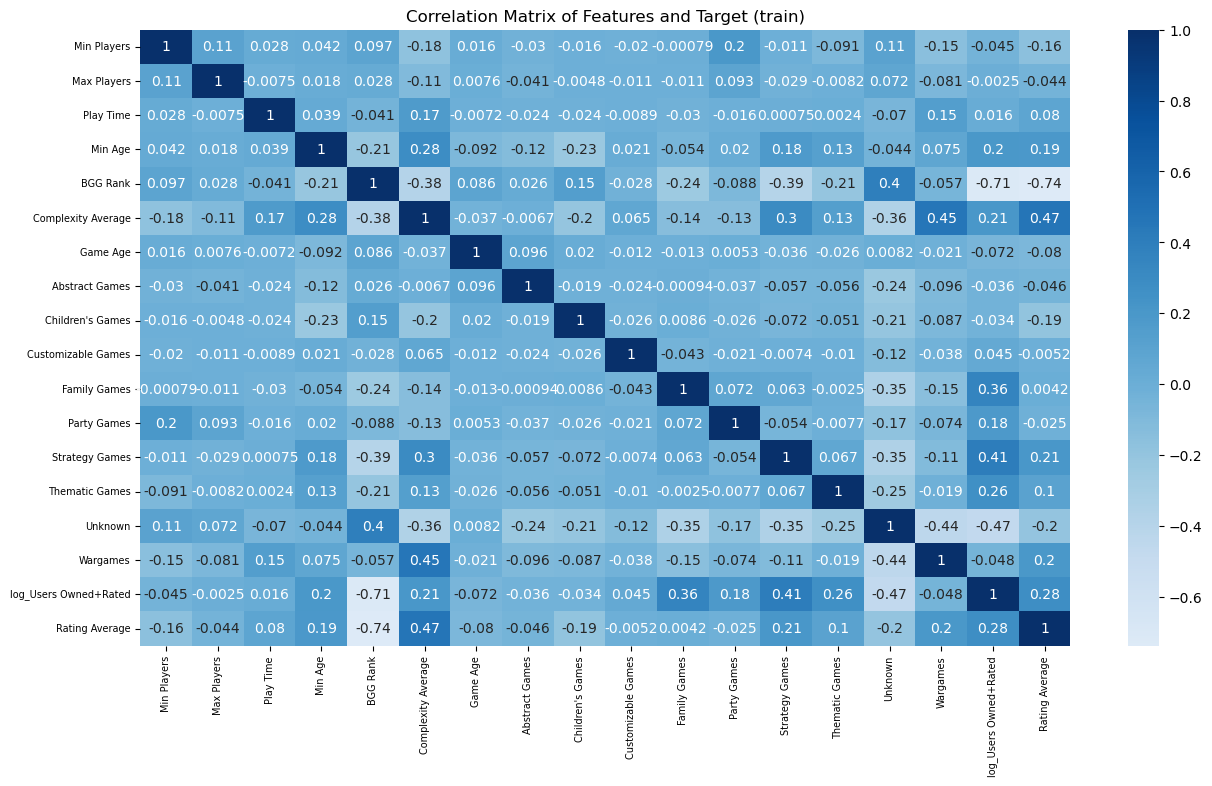

In [206]:
plt.figure(figsize=(15,8))

corr_matrix = train_scaled.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap='Blues', center=0, annot=True)

plt.title('Correlation Matrix of Features and Target (train)', fontsize=12)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.show()

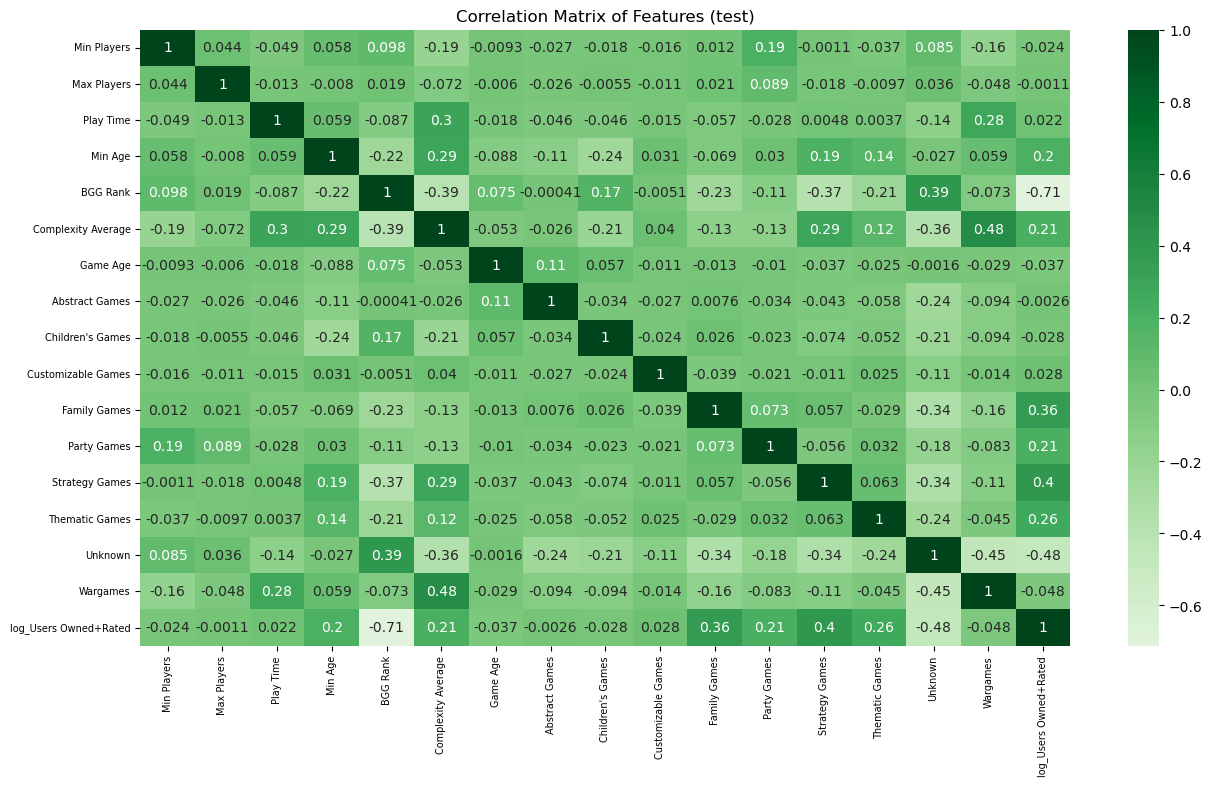

In [207]:
plt.figure(figsize=(15, 8))

corr_matrix = test_scaled.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap='Greens', center=0, annot=True)

plt.title('Correlation Matrix of Features (test)', fontsize=12)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()

In [208]:
# Применим изменения
train = train_scaled
test = test_scaled

In [209]:
test.shape

(5086, 17)

In [210]:
# Проверим, если колонки train и test совпадают
train.columns.drop([target_col]).equals(test.columns)


True

In [211]:
# Запомним наши признаки (фичи)
features = test.columns

In [212]:
features

Index(['Min Players', 'Max Players', 'Play Time', 'Min Age', 'BGG Rank',
       'Complexity Average', 'Game Age', 'Abstract Games', 'Children's Games',
       'Customizable Games', 'Family Games', 'Party Games', 'Strategy Games',
       'Thematic Games', 'Unknown', 'Wargames', 'log_Users Owned+Rated'],
      dtype='str')

# Вывод по предварительной обработке

Преобразовали данные, часть удалили, часть объединили. Теперь осталось их загрузить в модель. 


# Обучение нескольких моделей, их сравнение

## Разделение на обучающую и валидационную выборку


In [213]:
test.shape

(5086, 17)

In [214]:
# Отделение целевой переменной
X = train.drop(target_col, axis=1) # признаки
y = train[target_col]              # цель
X_pred = test

In [215]:
# Разделение на обучающую и валидационную выборку
# 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

In [216]:
X.shape, X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_pred.shape

((15257, 17), (10679, 17), (10679,), (4578, 17), (4578,), (5086, 17))

## Создаем модель линейной регрессии 

In [217]:

# Создаем модель линейной регрессии - т.е. прямой которая будет проходить через наши точки
# Эта операция создает переменную model в качестве экземпляра LinearRegression

lin_reg_model = LinearRegression()

# С помощью метода fit() применяем нашу модель к нашему набору данных - обучем модель
# С помощью .fit() вычисляются оптимальные значение весов w₀ и w₁ и т.д,
# используя существующие вход и выход (x и y) в качестве аргументов.

lin_reg_model.fit(X_train, y_train)

y_pred = lin_reg_model.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

Mean Absolute Error: 0.36816833136122235
Mean Squared Error: 0.267270957794017
R2 score: 0.6987127491032294


In [218]:
# создание случайных фолдов
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
# кросс-валидация                                            # чем ближе к 0, тем лучше
scores = cross_val_score(lin_reg_model, X, y, cv=kf, scoring='neg_mean_squared_error')
# ...                                          # 
scores_r2 = cross_val_score(lin_reg_model, X, y, cv=kf, scoring='r2')

scores = cross_val_score(lin_reg_model, X, y, cv=kf, scoring='neg_mean_squared_error')
scores_r2 = cross_val_score(lin_reg_model, X, y, cv=kf, scoring='r2')

print("neg_MSE на каждом фолде:", scores)
print("Среднее neg_MSE:", np.mean(scores))
print("R2 на каждом фолде:", scores_r2)
print("Среднее R2:", np.mean(scores_r2))

neg_MSE на каждом фолде: [-0.27324833 -0.24714801 -0.24969478 -0.23882904 -0.26498902]
Среднее neg_MSE: -0.2547818346340113
R2 на каждом фолде: [0.69954299 0.71247514 0.71370082 0.72406974 0.69805156]
Среднее R2: 0.7095680515686625


Метрики достаточно сбалансированы и не прыгют.

$R^2$ (коэффициент детерминации) — это метрика, которая показывает, насколько хорошо модель объясняет разброс данных.

## Сравнение модели *Ridge* и *Random Forest*

In [219]:
# RandomForest (не требует масштабирования, ловит нелинейности)
rf_model = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_final_RF = rf_model.predict(X_pred)

# Оценка
pred = rf_model.predict(X_test)
print(f"R2: {r2_score(y_test, pred):.4f} | MSE: {mean_squared_error(y_test, pred):.4f}")

R2: 0.8985 | MSE: 0.0900


Random Forest показывает отличный результат! $0.09$

## Обучение модели *Ridge*

Ridge лучше обычной регрессии, так как сглаживает влияние шумных признаков.

In [220]:
# Автоматический подбор alpha для Ridge
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=kf)
ridge_cv.fit(X_train, y_train)
print(f"Лучший alpha для Ridge: {ridge_cv.alpha_}")

Лучший alpha для Ridge: 6.158482110660261


In [221]:
# Создание
model = Ridge(alpha=6.158482110660261) # подобраный гиперпараметр
model.fit(X_train, y_train)

# Проверка результата
y_pred_Ridge = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_Ridge)

y_pred_final_Ridge = model.predict(X_pred)

print(f"Ваш MSE на валидации: {mse:.5f}")

# Посмотрим, какие признаки оказались самыми важными
coeffs = pd.DataFrame({'feature': features, 'coeff': model.coef_})
print("\nВлияние признаков:\n", coeffs.sort_values(by='coeff', ascending=False))

Ваш MSE на валидации: 0.26725

Влияние признаков:
                   feature     coeff
5      Complexity Average  0.141092
14                Unknown  0.050789
15               Wargames  0.050266
2               Play Time  0.040980
3                 Min Age  0.017324
11            Party Games  0.010591
1             Max Players  0.001513
8        Children's Games -0.002348
13         Thematic Games -0.007385
9      Customizable Games -0.015410
7          Abstract Games -0.016195
6                Game Age -0.017770
12         Strategy Games -0.031605
10           Family Games -0.037231
0             Min Players -0.051037
16  log_Users Owned+Rated -0.400805
4                BGG Rank -0.951437


In [222]:
# кросс-валидация 
scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
# 
scores_r2 = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("neg_MSE на каждом фолде:", scores)
print("Среднее neg_MSE:", np.mean(scores))
print("R2 на каждом фолде:", scores_r2)
print("Среднее R2:", np.mean(scores_r2))

neg_MSE на каждом фолде: [-0.27321573 -0.24715604 -0.2497226  -0.23882297 -0.26498601]
Среднее neg_MSE: -0.25478067127898174
R2 на каждом фолде: [0.69957883 0.71246579 0.71366892 0.72407675 0.69805499]
Среднее R2: 0.7095690583231777


## Тест модели *GradientBoostingRegressor*

In [223]:
# Протестируем на параметре max_depth=3
#
# Создание модели
gb_model = GradientBoostingRegressor(
    n_estimators=100,      # количество деревьев
    learning_rate=0.1,     # шаг обучения (меньше → стабильнее, но дольше учится)
    max_depth=3,           # глубина деревьев (3-5 обычно оптимально)
    subsample=0.8,         # доля объектов для каждого дерева (защита от переобучения)
    random_state=SEED
)

# Обучение
gb_model.fit(X_train, y_train)

# Оценка на валидации
y_pred_GB = gb_model.predict(X_test)
print(f"GradientBoosting | MAE: {mean_absolute_error(y_test, y_pred_GB):.4f} | "
      f"MSE: {mean_squared_error(y_test, y_pred_GB):.4f} | "
      f"R2: {r2_score(y_test, y_pred_GB):.4f}")

# Кросс-валидация
cv_mse_gb = cross_val_score(gb_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_r2_gb = cross_val_score(gb_model, X, y, cv=5, scoring='r2')
print(f"CV neg_MSE: {cv_mse_gb.mean():.4f} ± {cv_mse_gb.std():.4f}")
print(f"CV R2:      {cv_r2_gb.mean():.4f} ± {cv_r2_gb.std():.4f}")

# Важность признаков
feat_imp = pd.DataFrame({
    'feature': features, 
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nВажность признаков (GradientBoosting):")
print(feat_imp.head(10))

# Финальный прогноз для сабмита
y_pred_final_GB_3 = gb_model.predict(X_pred)
sub_gb = pd.DataFrame(y_pred_final_GB_3, columns=['Rating Average']).reset_index()
sub_gb.to_csv('./games-rating/GB_3_submit_v1.csv', index=False)

GradientBoosting | MAE: 0.2179 | MSE: 0.1069 | R2: 0.8795
CV neg_MSE: -0.3892 ± 0.2693
CV R2:      -0.1309 ± 0.7518

Важность признаков (GradientBoosting):
                  feature  importance
4                BGG Rank    0.768579
6                Game Age    0.076369
5      Complexity Average    0.065818
16  log_Users Owned+Rated    0.064223
15               Wargames    0.008211
2               Play Time    0.007576
1             Max Players    0.005997
3                 Min Age    0.001608
0             Min Players    0.000740
12         Strategy Games    0.000696


In [224]:
# Протестируем на параметре max_depth=5
#
# Создание модели
gb_model = GradientBoostingRegressor(
    n_estimators=100,      # количество деревьев
    learning_rate=0.1,     # шаг обучения (меньше → стабильнее, но дольше учится)
    max_depth=5,           # глубина деревьев (3-5 обычно оптимально)
    subsample=0.8,         # доля объектов для каждого дерева (защита от переобучения)
    random_state=SEED
)

# Обучение
gb_model.fit(X_train, y_train)

# Оценка на валидации
y_pred_GB = gb_model.predict(X_test)
print(f"GradientBoosting | MAE: {mean_absolute_error(y_test, y_pred_GB):.4f} | "
      f"MSE: {mean_squared_error(y_test, y_pred_GB):.4f} | "
      f"R2: {r2_score(y_test, y_pred_GB):.4f}")

# Кросс-валидация
cv_mse_gb = cross_val_score(gb_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_r2_gb = cross_val_score(gb_model, X, y, cv=5, scoring='r2')
print(f"CV neg_MSE: {cv_mse_gb.mean():.4f} ± {cv_mse_gb.std():.4f}")
print(f"CV R2:      {cv_r2_gb.mean():.4f} ± {cv_r2_gb.std():.4f}")

# Важность признаков
feat_imp = pd.DataFrame({
    'feature': features, 
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nВажность признаков (GradientBoosting):")
print(feat_imp.head(10))

# Финальный прогноз для сабмита
y_pred_final_GB_5 = gb_model.predict(X_pred)
sub_gb = pd.DataFrame(y_pred_final_GB_5, columns=['Rating Average']).reset_index()
sub_gb.to_csv('./games-rating/GB_5_submit_v1.csv', index=False)

GradientBoosting | MAE: 0.1855 | MSE: 0.0821 | R2: 0.9075
CV neg_MSE: -0.3996 ± 0.2987
CV R2:      -0.1932 ± 0.9158

Важность признаков (GradientBoosting):
                  feature  importance
4                BGG Rank    0.741302
16  log_Users Owned+Rated    0.083912
6                Game Age    0.072103
5      Complexity Average    0.067198
2               Play Time    0.011584
1             Max Players    0.007139
15               Wargames    0.006972
3                 Min Age    0.004836
0             Min Players    0.001819
14                Unknown    0.001388


In [225]:
# Протестируем на параметре max_depth=7
#
# Создание модели
gb_model = GradientBoostingRegressor(
    n_estimators=200,      # количество деревьев
    learning_rate=0.05,     # шаг обучения (меньше → стабильнее, но дольше учится)
    max_depth=7,           # глубина деревьев (3-5 обычно оптимально)
    subsample=0.8,         # доля объектов для каждого дерева (защита от переобучения)
    random_state=SEED
)

# Обучение
gb_model.fit(X_train, y_train)

# Оценка на валидации
y_pred_GB = gb_model.predict(X_test)
print(f"GradientBoosting | MAE: {mean_absolute_error(y_test, y_pred_GB):.4f} | "
      f"MSE: {mean_squared_error(y_test, y_pred_GB):.4f} | "
      f"R2: {r2_score(y_test, y_pred_GB):.4f}")

# Кросс-валидация
cv_mse_gb = cross_val_score(gb_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_r2_gb = cross_val_score(gb_model, X, y, cv=5, scoring='r2')
print(f"CV neg_MSE: {cv_mse_gb.mean():.4f} ± {cv_mse_gb.std():.4f}")
print(f"CV R2:      {cv_r2_gb.mean():.4f} ± {cv_r2_gb.std():.4f}")

# Важность признаков
feat_imp = pd.DataFrame({
    'feature': features, 
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nВажность признаков (GradientBoosting):")
print(feat_imp.head(10))

# Финальный прогноз для сабмита
y_pred_final_GB_7 = gb_model.predict(X_pred)
sub_gb = pd.DataFrame(y_pred_final_GB_7, columns=['Rating Average']).reset_index()
sub_gb.to_csv('./games-rating/GB_7_200_submit_v1.csv', index=False)

GradientBoosting | MAE: 0.1782 | MSE: 0.0786 | R2: 0.9114
CV neg_MSE: -0.3656 ± 0.2916
CV R2:      -0.0846 ± 0.8624

Важность признаков (GradientBoosting):
                  feature  importance
4                BGG Rank    0.715733
16  log_Users Owned+Rated    0.089795
6                Game Age    0.075848
5      Complexity Average    0.073809
2               Play Time    0.013443
1             Max Players    0.010431
3                 Min Age    0.006953
15               Wargames    0.006368
0             Min Players    0.002733
14                Unknown    0.001844


## Вывод по обучению модели

Лучшие результаты показали модели Random Forest и Gradent Boosting. Последний ещё и указывает на важность признака, у нас это "BGG Rank", чуть ли не прямая указка на рейтинг, если его уберут (не подадут на test), то модель расстроится и будет плохо предсказывать. 

С увеличением максимальной глубины, ошибка пдадает. Лучший результат с параметрами: ```n_estimators=200, learning_rate=0.05, max_depth=7```. **Вывод:** берём эту модель для финального сабмита.

# Финальный сабмит

In [226]:
submition = pd.DataFrame(y_pred_final_GB_7, columns=['Rating Average'])
submition = submition.reset_index()
submition.to_csv('./games-rating/GB_7_5_200_all_numeric_domains_submit_v1.csv', index=False)

![Kaggle sumbit](Board_Game_Rating_Prediction_DZ_4_Kaggle_1.png)
![Kaggle sumbit](Board_Game_Rating_Prediction_DZ_4_Kaggle_2.png)